Shape of dataset: (18, 8)
  PatientID  Age  Gender          DateTime SeverityLevel  Score     Doctor  \
0     P1029   59    Male  12/02/2026 11:15       Level 4    130  Dr. Ahmed   
1     P1030   42  Female   22/02/2026 8:55       Level 3    100  Dr. Ahmed   
2     P1031   60    Male  22/02/2026 20:05       Level 2     14   Dr. Sara   
3     P1032   80   Other  20/02/2026 20:10       Level 5    165   Dr. Noor   
4     P1033   15  Female  18/02/2026 23:15       Level 3     87   Dr. Sara   

       Status  
0  Discharged  
1  Discharged  
2  Discharged  
3  discharged  
4  Discharged  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   PatientID      18 non-null     object
 1   Age            18 non-null     int64 
 2   Gender         18 non-null     object
 3   DateTime       18 non-null     object
 4   SeverityLevel  18 non-null     object
 5   S

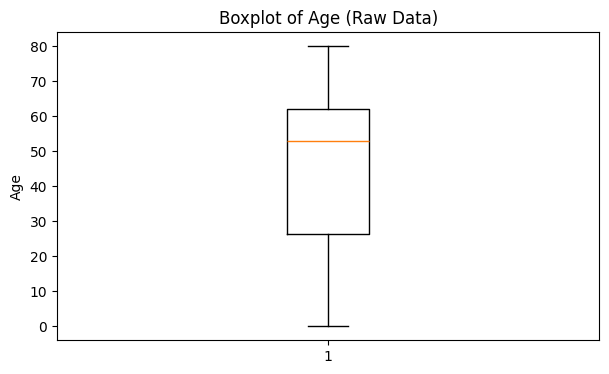

Shape after cleaning: (17, 8)
PatientID        0
Age              0
Gender           0
DateTime         0
SeverityLevel    0
Score            0
Doctor           0
Status           0
dtype: int64
Duplicates after cleaning: 0
Clean Severity Levels: ['Level 4' 'Level 3' 'Level 2' 'Level 5']
Clean Status: ['Discharged' 'Admitted' 'Transferred']
             Frequency  Percentage
Status                            
Discharged          13       76.47
Admitted             3       17.65
Transferred          1        5.88


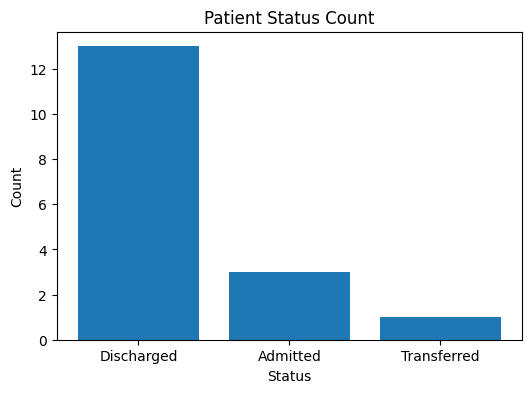

count     17.000000
mean      83.470588
std       44.507187
min       14.000000
25%       46.000000
50%       86.000000
75%      121.000000
max      165.000000
Name: Score, dtype: float64


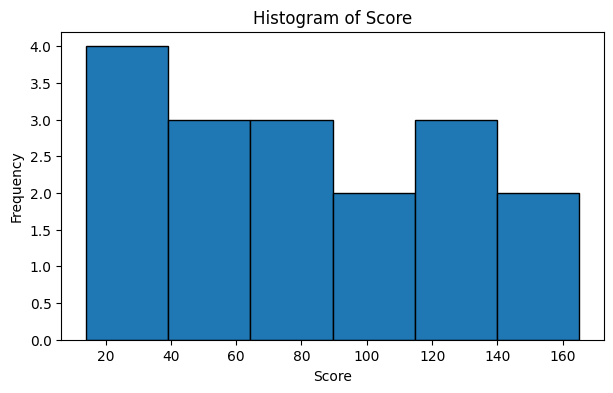

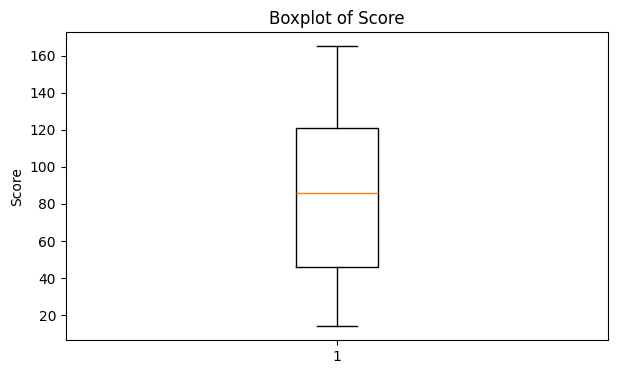

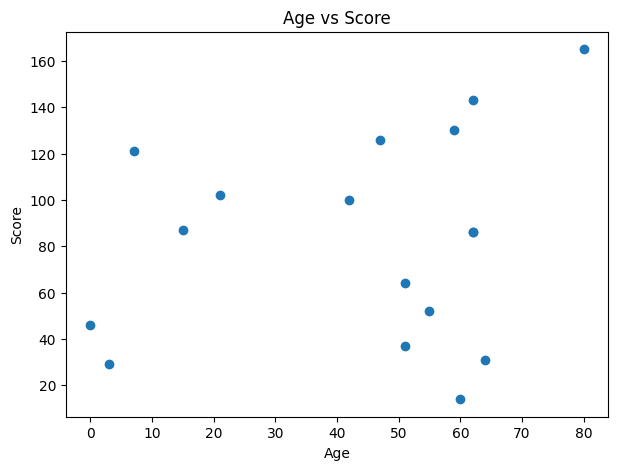

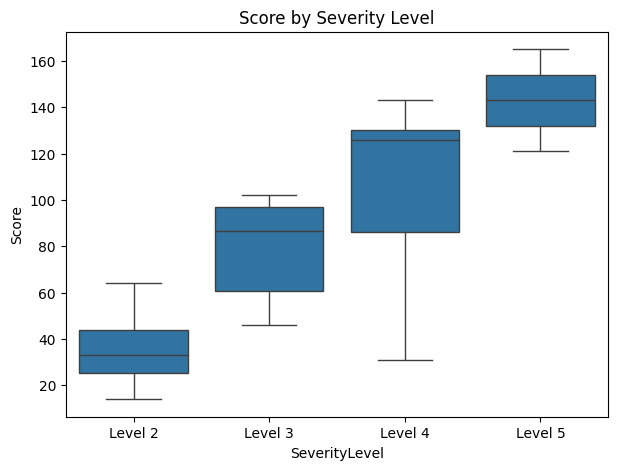

Status         Admitted  Discharged  Transferred
SeverityLevel                                   
Level 2               0           4            0
Level 3               2           4            0
Level 4               1           4            0
Level 5               0           1            1


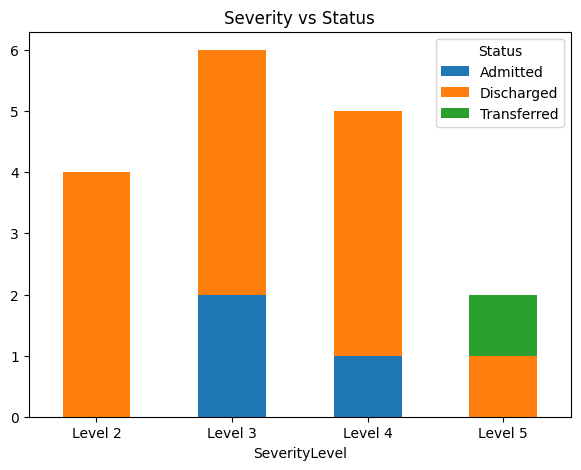

            Age     Score
Age    1.000000  0.221257
Score  0.221257  1.000000


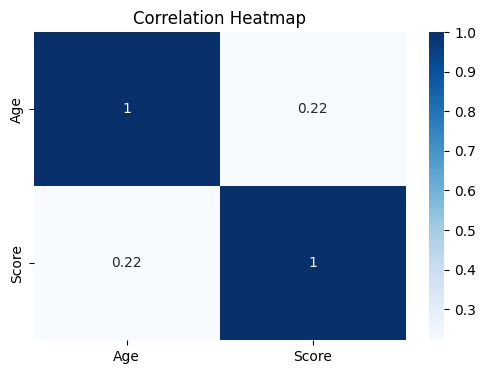

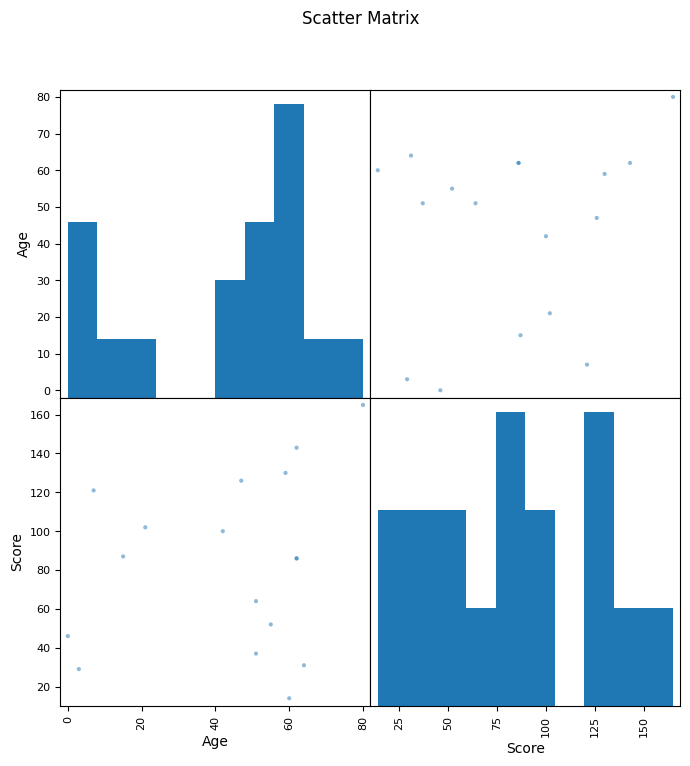

EDA Findings:
1. Dataset contains 17 patients.
2. Most patients are discharged.
3. Higher severity levels tend to have higher scores.
4. Age has a weak relationship with score.
5. Severity Level impacts patient outcomes.


In [1]:
# Hospital Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix
# STEP 1: RANDOM DATA SET OF HOSPITAL PATIENTS FROM ASSIGNMENT 2 DATASET
data = {
    "PatientID": ["P1029","P1030","P1031","P1032","P1033","P1034","P1035","P1036","P1037","P1038","P1039","P1040","P1041","P1042","P1043","P1044","P1045"],
    "Age": [59,42,60,80,15,62,62,47,62,51,55,64,3,51,7,21,0],
    "Gender": ["Male","Female","Male","Other","Female","Female","Male","Male","Male","Female","Male","Male","Male","Female","Female","Female","Female"],
    "DateTime": [
        "12/02/2026 11:15","22/02/2026 8:55","22/02/2026 20:05","20/02/2026 20:10",
        "18/02/2026 23:15","06/02/2026 14:30","09/02/2026 20:55","18/02/2026 7:50",
        "11/02/2026 1:15","27/02/2026 1:25","13/02/2026 8:05","07/02/2026 18:55",
        "11/02/2026 6:50","16/02/2026 12:50","15/02/2026 4:30","05/02/2026 7:55",
        "18/02/2026 17:20"
    ],
    "SeverityLevel": ["Level 4","Level 3","Level 2","Level 5","Level 3","Level 3","Level 4","Level 4","Level 4","Level 2","Level 3","Level 4","Level 2","Level 2","Level 5","Level 3","Level 3"],
    "Score": [130,100,14,165,87,86,143,126,86,64,52,31,29,37,121,102,46],
    "Doctor": ["Dr. Ahmed","Dr. Ahmed","Dr. Sara","Dr. Noor","Dr. Sara","Dr. Sara","Dr. Sara","Dr. Sara","Dr. Ali","Dr. Ahmed","Dr. Ali","Dr. Noor","Dr. Sara","Dr. Khan","Dr. Sara","Dr. Noor","Dr. Ahmed"],
    "Status": ["Discharged","Discharged","Discharged","discharged","Discharged","Discharged","Discharged","Admitted","Discharged","Discharged","Admitted","Discharged","Discharged","Discharged","Transferred","Discharged","Admitted"]
}
raw_df = pd.DataFrame(data)

raw_df = pd.concat([raw_df, raw_df.iloc[[8]]], ignore_index=True)
# STEP 2: BASIC INFO
print("Shape of dataset:", raw_df.shape)
print(raw_df.head())
print(raw_df.info())
# STEP 3: VARIABLE TYPES
variable_types = pd.DataFrame({
    "Variable": raw_df.columns,
    "Suggested Type": ["ID", "Numerical", "Categorical", "Datetime", "Categorical", "Numerical", "Categorical", "Categorical"]
})
print(variable_types)
# STEP 4: DATA QUALITY CHECKS
print("Missing values:\n", raw_df.isnull().sum())
print("Duplicate rows:", raw_df.duplicated().sum())
print("Unique Severity Levels:", raw_df["SeverityLevel"].unique())
print("Unique Status:", raw_df["Status"].unique())
# Invalid values
invalid_age = raw_df[raw_df["Age"] < 0]
invalid_score = raw_df[(raw_df["Score"] < 0)]
print("Invalid Age:\n", invalid_age)
print("Invalid Score:\n", invalid_score)
# STEP 5: RAW VISUALIZATION
plt.figure(figsize=(7,4))
plt.boxplot(raw_df["Age"])
plt.title("Boxplot of Age (Raw Data)")
plt.ylabel("Age")
plt.show()
# STEP 6: DATA CLEANING
clean_df = raw_df.copy()
# Fix text inconsistencies
clean_df["SeverityLevel"] = clean_df["SeverityLevel"].str.strip().str.title()
clean_df["Status"] = clean_df["Status"].str.strip().str.title()
# Convert datetime
clean_df["DateTime"] = pd.to_datetime(clean_df["DateTime"], dayfirst=True)
# Remove duplicates
clean_df = clean_df.drop_duplicates()
# STEP 7: CLEANED DATA CHECK
print("Shape after cleaning:", clean_df.shape)
print(clean_df.isnull().sum())
print("Duplicates after cleaning:", clean_df.duplicated().sum())
print("Clean Severity Levels:", clean_df["SeverityLevel"].unique())
print("Clean Status:", clean_df["Status"].unique())
# STEP 8: STATUS ANALYSIS

status_counts = clean_df["Status"].value_counts()
status_percent = clean_df["Status"].value_counts(normalize=True) * 100
status_summary = pd.DataFrame({
    "Frequency": status_counts,
    "Percentage": status_percent.round(2)
})
print(status_summary)
plt.figure(figsize=(6,4))
plt.bar(status_counts.index, status_counts.values)
plt.title("Patient Status Count")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()
# STEP 9: SCORE ANALYSIS
score_summary = clean_df["Score"].describe()
print(score_summary)
plt.figure(figsize=(7,4))
plt.hist(clean_df["Score"], bins=6, edgecolor="black")
plt.title("Histogram of Score")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()
plt.figure(figsize=(7,4))
plt.boxplot(clean_df["Score"])
plt.title("Boxplot of Score")
plt.ylabel("Score")
plt.show()
# STEP 10: RELATIONSHIPS
plt.figure(figsize=(7,5))
plt.scatter(clean_df["Age"], clean_df["Score"])
plt.title("Age vs Score")
plt.xlabel("Age")
plt.ylabel("Score")
plt.show()
plt.figure(figsize=(7,5))
sns.boxplot(data=clean_df, x="SeverityLevel", y="Score", order=["Level 2","Level 3","Level 4","Level 5"])
plt.title("Score by Severity Level")
plt.show()
# STEP 11: CROSSTAB
crosstab = pd.crosstab(clean_df["SeverityLevel"], clean_df["Status"])
print(crosstab)
crosstab.plot(kind="bar", stacked=True, figsize=(7,5))
plt.title("Severity vs Status")
plt.xticks(rotation=0)
plt.show()
# STEP 12: CORRELATION
numeric_cols = ["Age", "Score"]
corr_matrix = clean_df[numeric_cols].corr()
print(corr_matrix)
plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()
# STEP 13: SCATTER MATRIX
scatter_matrix(clean_df[numeric_cols], figsize=(8,8), diagonal="hist")
plt.suptitle("Scatter Matrix")
plt.show()
# STEP 14: FINAL INSIGHTS
print("EDA Findings:")
print("1. Dataset contains", clean_df.shape[0], "patients.")
print("2. Most patients are discharged.")
print("3. Higher severity levels tend to have higher scores.")
print("4. Age has a weak relationship with score.")
print("5. Severity Level impacts patient outcomes.")


Shape: (16, 8)
  PropertyID      Price  Area_sqft  Bedrooms  Bathrooms  Location  \
0       PR01  5000000.0       1200         2          2     Urban   
1       PR02  7500000.0       1800         3          3     Urban   
2       PR03  6200000.0       1500         3          2  Suburban   
3       PR04  4500000.0       1000         2          1     Urban   
4       PR05  9000000.0       2000         4          4  Suburban   

  PropertyType     Status  
0        House       Sold  
1    Apartment  Available  
2        House       Sold  
3    Apartment  Available  
4        House       Sold  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PropertyID    16 non-null     object 
 1   Price         15 non-null     float64
 2   Area_sqft     16 non-null     int64  
 3   Bedrooms      16 non-null     int64  
 4   Bathrooms     16 non-null     int64  

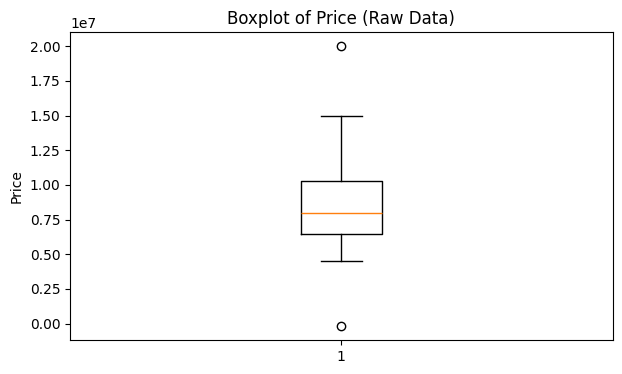

Median Price used: 8000000.0
Shape after cleaning: (15, 8)
PropertyID      0
Price           0
Area_sqft       0
Bedrooms        0
Bathrooms       0
Location        0
PropertyType    0
Status          0
dtype: int64
Duplicates after cleaning: 0
           Frequency  Percentage
Status                          
Sold               9        60.0
Available          6        40.0


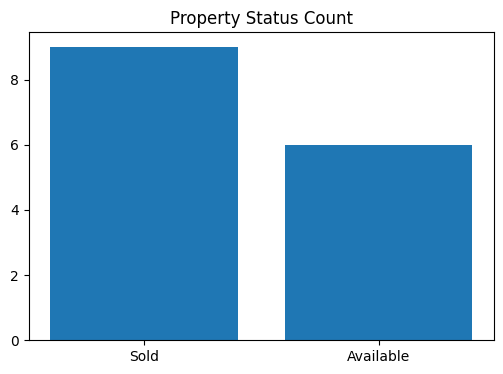

count    1.500000e+01
mean     9.173333e+06
std      4.032629e+06
min      4.500000e+06
25%      6.950000e+06
50%      8.000000e+06
75%      1.025000e+07
max      2.000000e+07
Name: Price, dtype: float64


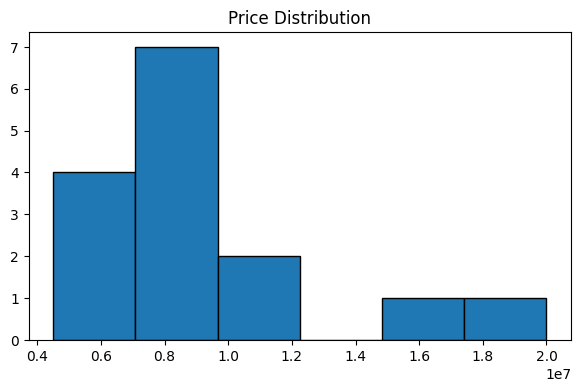

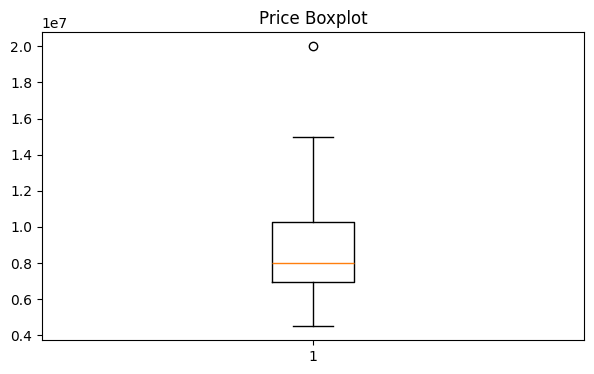

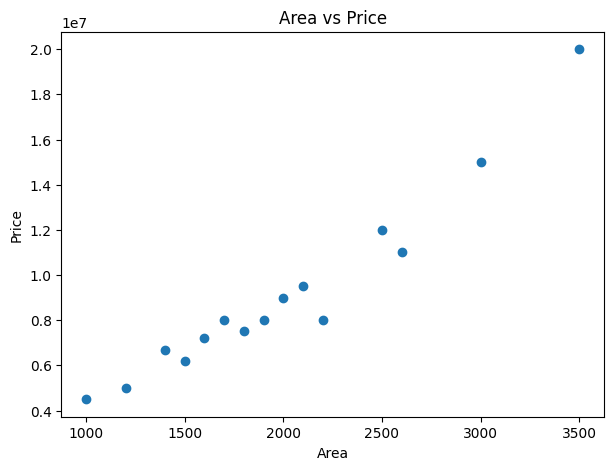

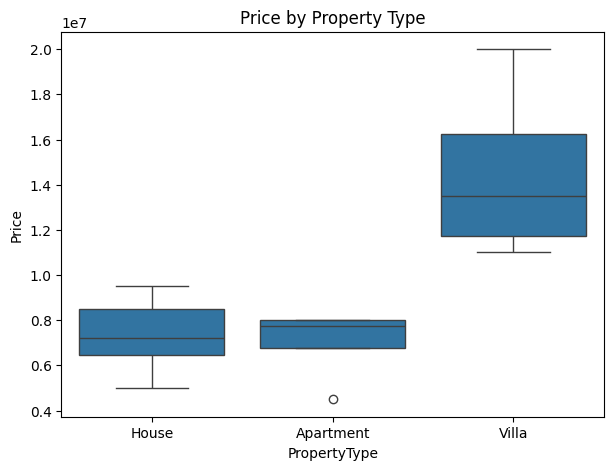

Status    Available  Sold
Location                 
Rural             1     1
Suburban          0     6
Urban             5     2


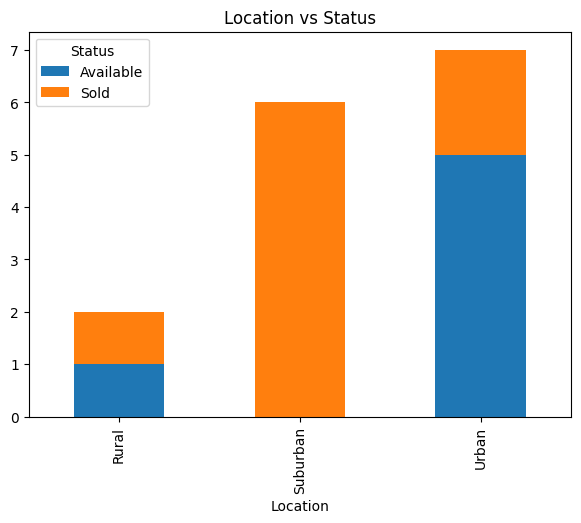

           Price  Area_sqft  Bedrooms  Bathrooms
Price       1.00       0.96      0.96       0.91
Area_sqft   0.96       1.00      0.98       0.93
Bedrooms    0.96       0.98      1.00       0.95
Bathrooms   0.91       0.93      0.95       1.00


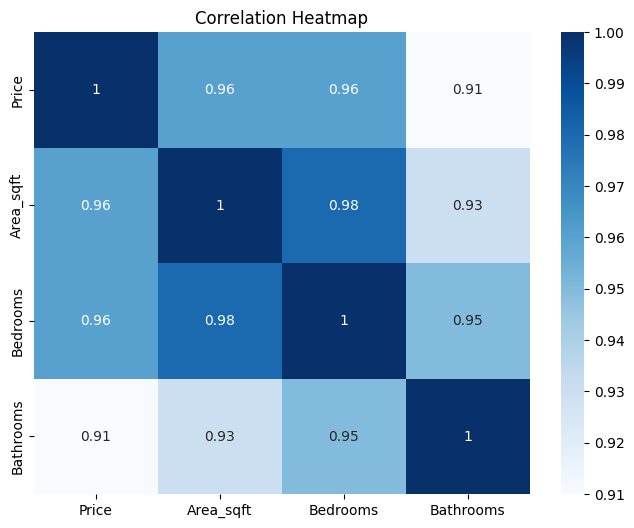

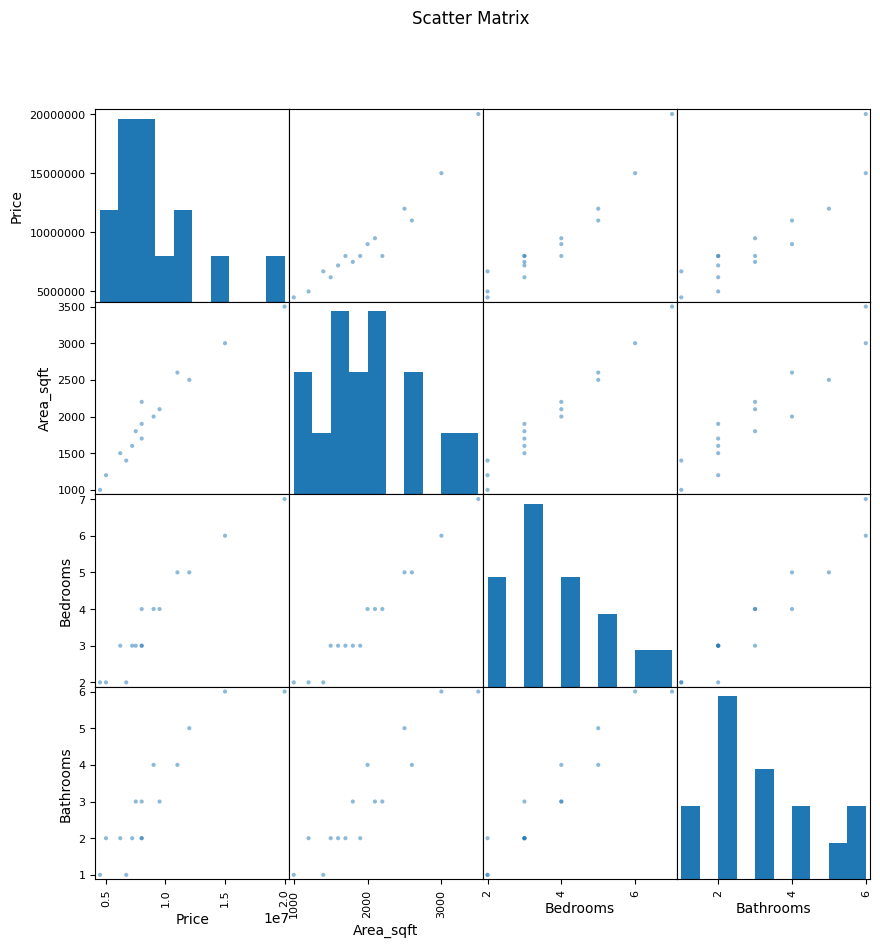

EDA Findings:
1. Dataset contains 15 properties.
2. Most properties are sold.
3. Larger area generally means higher price.
4. Villas tend to have higher prices.
5. Price strongly correlates with area and number of rooms.


In [2]:
# Property Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix
# STEP 1: PROPERTY DATASET
data = {
    "PropertyID": ["PR01","PR02","PR03","PR04","PR05","PR06","PR07","PR08","PR09","PR10","PR11","PR12","PR13","PR14","PR15"],
    "Price": [5000000, 7500000, 6200000, 4500000, 9000000, 12000000, 15000000, np.nan, 8000000, 9500000, -200000, 6700000, 11000000, 20000000, 7200000],
    "Area_sqft": [1200, 1800, 1500, 1000, 2000, 2500, 3000, 2200, 1700, 2100, 1900, 1400, 2600, 3500, 1600],
    "Bedrooms": [2,3,3,2,4,5,6,4,3,4,3,2,5,7,3],
    "Bathrooms": [2,3,2,1,4,5,6,3,2,3,2,1,4,6,2],
    "Location": ["Urban","Urban","Suburban","Urban","Suburban","Suburban","Urban","Rural","Urban","Suburban","Urban","Rural","Suburban","Urban","Suburban"],
    "PropertyType": ["House","Apartment","House","Apartment","House","Villa","Villa","House","Apartment","House","Apartment","House","Villa","Villa","House"],
    "Status": ["Sold","Available","Sold","Available","Sold","Sold","Available","Sold","Available","Sold","Sold ","Available","Sold","Available","Sold"]
}
raw_df = pd.DataFrame(data)
raw_df = pd.concat([raw_df, raw_df.iloc[[8]]], ignore_index=True)
# STEP 2: BASIC INFO
print("Shape:", raw_df.shape)
print(raw_df.head())
print(raw_df.info())
# STEP 3: VARIABLE TYPES
variable_types = pd.DataFrame({
    "Variable": raw_df.columns,
    "Suggested Type": ["ID","Numerical","Numerical","Numerical","Numerical","Categorical","Categorical","Categorical"]
})
print(variable_types)
# STEP 4: DATA QUALITY CHECKS
print("Missing values:\n", raw_df.isnull().sum())
print("Duplicate rows:", raw_df.duplicated().sum())
print("Unique Location:", raw_df["Location"].unique())
print("Unique Status:", raw_df["Status"].unique())
invalid_price = raw_df[raw_df["Price"] < 0]
print("Invalid Price:\n", invalid_price)
# STEP 5: RAW VISUALIZATION
plt.figure(figsize=(7,4))
plt.boxplot(raw_df["Price"].dropna())
plt.title("Boxplot of Price (Raw Data)")
plt.ylabel("Price")
plt.show()
# STEP 6: DATA CLEANING
clean_df = raw_df.copy()
clean_df["Status"] = clean_df["Status"].str.strip().str.title()
clean_df.loc[clean_df["Price"] < 0, "Price"] = np.nan
median_price = clean_df["Price"].median()
clean_df["Price"] = clean_df["Price"].fillna(median_price)
clean_df = clean_df.drop_duplicates()
# STEP 7: CLEAN CHECK
print("Median Price used:", median_price)
print("Shape after cleaning:", clean_df.shape)
print(clean_df.isnull().sum())
print("Duplicates after cleaning:", clean_df.duplicated().sum())
# STEP 8: STATUS ANALYSIS
status_counts = clean_df["Status"].value_counts()
status_percent = clean_df["Status"].value_counts(normalize=True) * 100
status_summary = pd.DataFrame({
    "Frequency": status_counts,
    "Percentage": status_percent.round(2)
})
print(status_summary)
plt.figure(figsize=(6,4))
plt.bar(status_counts.index, status_counts.values)
plt.title("Property Status Count")
plt.show()
# STEP 9: PRICE ANALYSIS
price_summary = clean_df["Price"].describe()
print(price_summary)
plt.figure(figsize=(7,4))
plt.hist(clean_df["Price"], bins=6, edgecolor="black")
plt.title("Price Distribution")
plt.show()
plt.figure(figsize=(7,4))
plt.boxplot(clean_df["Price"])
plt.title("Price Boxplot")
plt.show()

# STEP 10: RELATIONSHIPS
plt.figure(figsize=(7,5))
plt.scatter(clean_df["Area_sqft"], clean_df["Price"])
plt.title("Area vs Price")
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()
plt.figure(figsize=(7,5))
sns.boxplot(data=clean_df, x="PropertyType", y="Price")
plt.title("Price by Property Type")
plt.show()

# STEP 11: CROSSTAB
crosstab = pd.crosstab(clean_df["Location"], clean_df["Status"])
print(crosstab)
crosstab.plot(kind="bar", stacked=True, figsize=(7,5))
plt.title("Location vs Status")
plt.show()

# STEP 12: CORRELATION
numeric_cols = ["Price","Area_sqft","Bedrooms","Bathrooms"]
corr_matrix = clean_df[numeric_cols].corr().round(2)
print(corr_matrix)

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()

# STEP 13: SCATTER MATRIX

scatter_matrix(clean_df[numeric_cols], figsize=(10,10), diagonal="hist")
plt.suptitle("Scatter Matrix")
plt.show()

# STEP 14: INSIGHTS

print("EDA Findings:")
print("1. Dataset contains", clean_df.shape[0], "properties.")
print("2. Most properties are sold.")
print("3. Larger area generally means higher price.")
print("4. Villas tend to have higher prices.")
print("5. Price strongly correlates with area and number of rooms.")


Shape: (16, 8)
  StudentID  Age  Gender Department  CGPA  Attendance  StudyHours Status
0      SZ01   20    Male         CS   2.5          65           2   Pass
1      SZ02   21  Female        BBA   3.2          78           4   Pass
2      SZ03   22    Male         CS   3.8          88           6   Pass
3      SZ04   19  Female         SE   2.9          70           3   Pass
4      SZ05   23    Male         CS   3.5          82           7   Pass
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   StudentID   16 non-null     object 
 1   Age         16 non-null     int64  
 2   Gender      16 non-null     object 
 3   Department  16 non-null     object 
 4   CGPA        15 non-null     float64
 5   Attendance  16 non-null     int64  
 6   StudyHours  16 non-null     int64  
 7   Status      16 non-null     object 
dtypes: float64(1), int64(3), objec

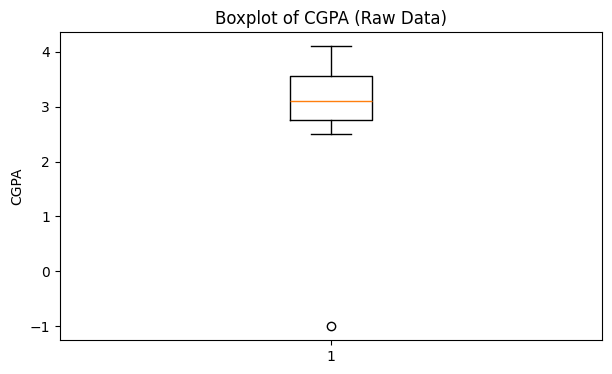

Median CGPA used: 3.1
Shape after cleaning: (15, 8)
StudentID     0
Age           0
Gender        0
Department    0
CGPA          0
Attendance    0
StudyHours    0
Status        0
dtype: int64
Duplicates after cleaning: 0
        Frequency  Percentage
Status                       
Pass           12        80.0
Fail            3        20.0


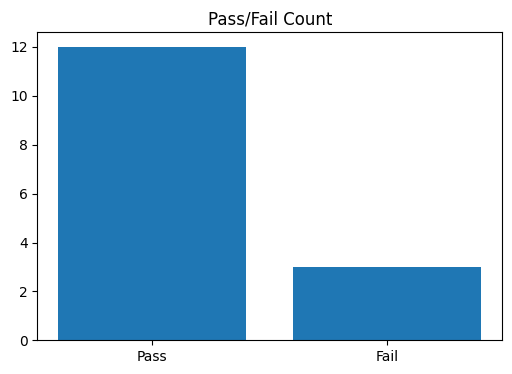

count    15.000000
mean      3.180000
std       0.396773
min       2.500000
25%       2.950000
50%       3.100000
75%       3.450000
max       3.900000
Name: CGPA, dtype: float64


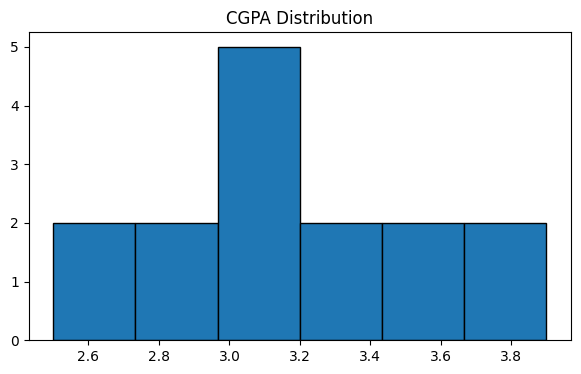

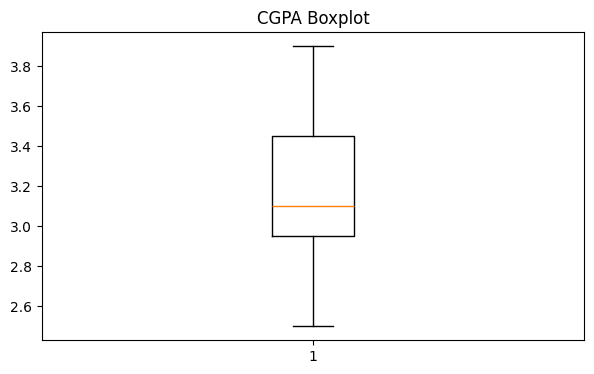

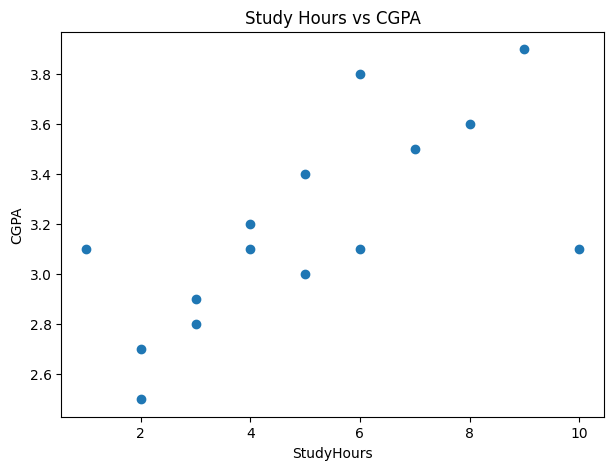

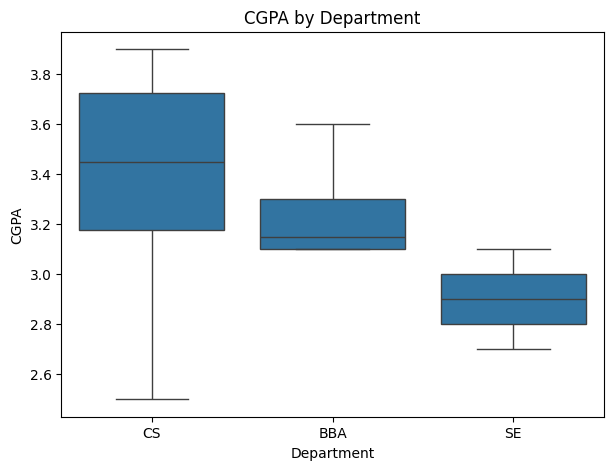

Status      Fail  Pass
Department            
BBA            0     4
CS             0     6
SE             3     2


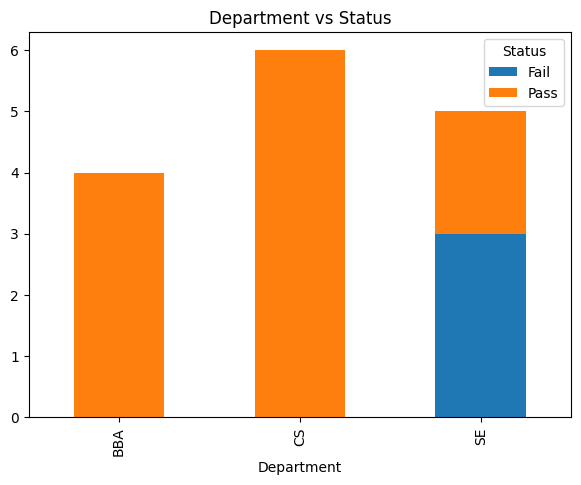

            CGPA  Attendance  StudyHours   Age
CGPA        1.00        0.72        0.68  0.41
Attendance  0.72        1.00        0.96  0.50
StudyHours  0.68        0.96        1.00  0.54
Age         0.41        0.50        0.54  1.00


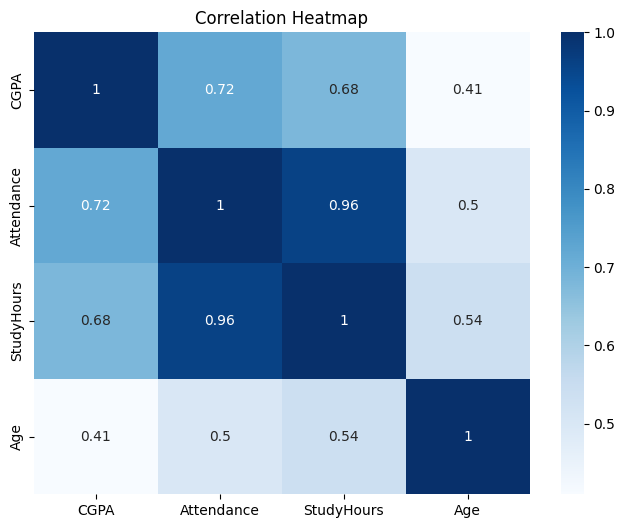

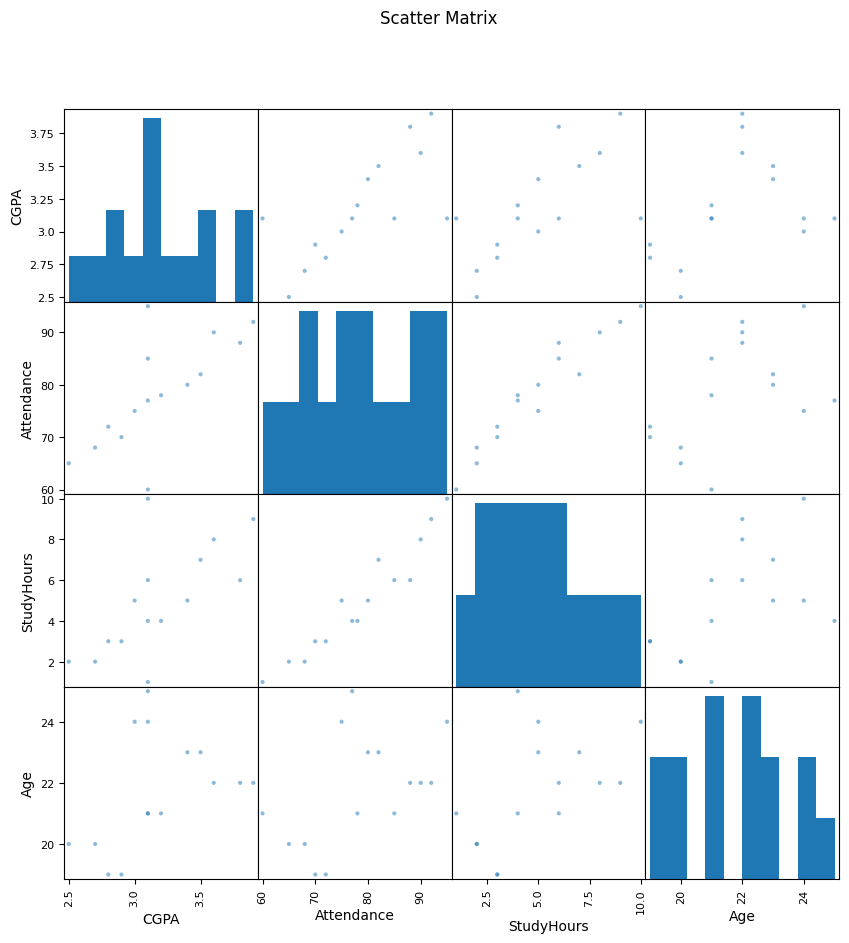

EDA Findings:
1. Dataset contains 15 students.
2. Most students passed.
3. Higher study hours generally lead to higher CGPA.
4. Attendance positively affects CGPA.
5. Some variation exists between departments.


In [4]:
# Szabist Students Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix
# STEP 1:  SZABIST STUDENTS DATA
data = {
    "StudentID": ["SZ01","SZ02","SZ03","SZ04","SZ05","SZ06","SZ07","SZ08","SZ09","SZ10","SZ11","SZ12","SZ13","SZ14","SZ15"],
    "Age": [20,21,22,19,23,24,22,21,20,23,25,19,22,24,21],
    "Gender": ["Male","Female","Male","Female","Male","Male","Female","Female","Male","Male","Male","Female","Female","Male","Female"],
    "Department": ["CS","BBA","CS","SE","CS","SE","BBA","CS","SE","CS","BBA","SE","CS","BBA","SE"],
    "CGPA": [2.5,3.2,3.8,2.9,3.5,3.0,3.6,np.nan,2.7,3.4,3.1,2.8,3.9,4.1,-1],
    "Attendance": [65,78,88,70,82,75,90,85,68,80,77,72,92,95,60],
    "StudyHours": [2,4,6,3,7,5,8,6,2,5,4,3,9,10,1],
    "Status": ["Pass","Pass","Pass","Pass","Pass","Pass","Pass","pass","Fail","Pass","Pass ","Fail","Pass","Pass","Fail"]
}

raw_df = pd.DataFrame(data)
raw_df = pd.concat([raw_df, raw_df.iloc[[8]]], ignore_index=True)
# STEP 2: BASIC INFO
print("Shape:", raw_df.shape)
print(raw_df.head())
print(raw_df.info())
# STEP 3: VARIABLE TYPES
variable_types = pd.DataFrame({
    "Variable": raw_df.columns,
    "Suggested Type": ["ID","Numerical","Categorical","Categorical","Numerical","Numerical","Numerical","Categorical"]
})
print(variable_types)
# STEP 4: DATA QUALITY CHECKS

print("Missing values:\n", raw_df.isnull().sum())
print("Duplicate rows:", raw_df.duplicated().sum())
print("Unique Departments:", raw_df["Department"].unique())
print("Unique Status:", raw_df["Status"].unique())
invalid_cgpa = raw_df[(raw_df["CGPA"] < 0) | (raw_df["CGPA"] > 4)]
print("Invalid CGPA:\n", invalid_cgpa)
# STEP 5: RAW VISUALIZATION
plt.figure(figsize=(7,4))
plt.boxplot(raw_df["CGPA"].dropna())
plt.title("Boxplot of CGPA (Raw Data)")
plt.ylabel("CGPA")
plt.show()
# STEP 6: DATA CLEANING
clean_df = raw_df.copy()
clean_df["Status"] = clean_df["Status"].str.strip().str.title()
clean_df["Department"] = clean_df["Department"].str.strip().str.upper()
clean_df.loc[(clean_df["CGPA"] < 0) | (clean_df["CGPA"] > 4), "CGPA"] = np.nan
median_cgpa = clean_df["CGPA"].median()
clean_df["CGPA"] = clean_df["CGPA"].fillna(median_cgpa)
clean_df = clean_df.drop_duplicates()
# STEP 7: CLEAN CHECK
print("Median CGPA used:", median_cgpa)
print("Shape after cleaning:", clean_df.shape)
print(clean_df.isnull().sum())
print("Duplicates after cleaning:", clean_df.duplicated().sum())
# STEP 8: STATUS ANALYSIS
status_counts = clean_df["Status"].value_counts()
status_percent = clean_df["Status"].value_counts(normalize=True) * 100
status_summary = pd.DataFrame({
    "Frequency": status_counts,
    "Percentage": status_percent.round(2)
})
print(status_summary)
plt.figure(figsize=(6,4))
plt.bar(status_counts.index, status_counts.values)
plt.title("Pass/Fail Count")
plt.show()
# STEP 9: CGPA ANALYSIS
cgpa_summary = clean_df["CGPA"].describe()
print(cgpa_summary)
plt.figure(figsize=(7,4))
plt.hist(clean_df["CGPA"], bins=6, edgecolor="black")
plt.title("CGPA Distribution")
plt.show()
plt.figure(figsize=(7,4))
plt.boxplot(clean_df["CGPA"])
plt.title("CGPA Boxplot")
plt.show()
# STEP 10: RELATIONSHIPS
plt.figure(figsize=(7,5))
plt.scatter(clean_df["StudyHours"], clean_df["CGPA"])
plt.title("Study Hours vs CGPA")
plt.xlabel("StudyHours")
plt.ylabel("CGPA")
plt.show()
plt.figure(figsize=(7,5))
sns.boxplot(data=clean_df, x="Department", y="CGPA")
plt.title("CGPA by Department")
plt.show()
# STEP 11: CROSSTAB
crosstab = pd.crosstab(clean_df["Department"], clean_df["Status"])
print(crosstab)
crosstab.plot(kind="bar", stacked=True, figsize=(7,5))
plt.title("Department vs Status")
plt.show()
# STEP 12: CORRELATION
numeric_cols = ["CGPA","Attendance","StudyHours","Age"]
corr_matrix = clean_df[numeric_cols].corr().round(2)
print(corr_matrix)
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()
# STEP 13: SCATTER MATRIX
scatter_matrix(clean_df[numeric_cols], figsize=(10,10), diagonal="hist")
plt.suptitle("Scatter Matrix")
plt.show()
# STEP 14: INSIGHTS
print("EDA Findings:")
print("1. Dataset contains", clean_df.shape[0], "students.")
print("2. Most students passed.")
print("3. Higher study hours generally lead to higher CGPA.")
print("4. Attendance positively affects CGPA.")
print("5. Some variation exists between departments.")
